In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)
scalar = StandardScaler()
scalar.fit_transform(x_train)
scalar.fit_transform(x_test)

array([[ 0.3132457 , -0.81335423],
       [-0.17705192,  1.3915217 ],
       [ 2.27443615, -1.25432942],
       [ 0.19067129, -0.59286664],
       [ 1.17126652, -0.81335423],
       [-0.54477513,  0.50957133],
       [-0.29962632, -0.59286664],
       [ 1.29384092, -0.15189145],
       [ 0.4358201 , -2.13627979],
       [-0.05447751, -1.03384183],
       [ 0.80354331,  0.06859614],
       [-1.28022155, -0.37237905],
       [-0.42220072,  0.73005892],
       [-1.15764714, -0.15189145],
       [-0.91249834,  1.3915217 ],
       [ 0.5583945 ,  0.28908373],
       [ 0.80354331, -0.37237905],
       [-0.29962632, -1.47481701],
       [-0.17705192, -0.81335423],
       [ 0.68096891, -0.81335423],
       [-1.40279595,  0.06859614],
       [ 0.3132457 , -0.37237905],
       [-1.03507274,  0.50957133],
       [ 0.68096891, -0.81335423],
       [ 2.51958496,  1.3915217 ],
       [ 1.04869212, -0.37237905],
       [ 1.04869212, -1.47481701],
       [ 1.17126652,  0.06859614],
       [-1.28022155,

In [6]:
kernels = {
    "Linear" : SVC(kernel = "linear", C = 0.1),
    "Polynomial" : SVC(kernel = "poly", degree = 3, C = 1.0),
    "RBF" : SVC(kernel = "rbf", gamma = 'scale', C = 1.0),
    "Sigmoid" : SVC(kernel = "sigmoid", C = 1.0)
}

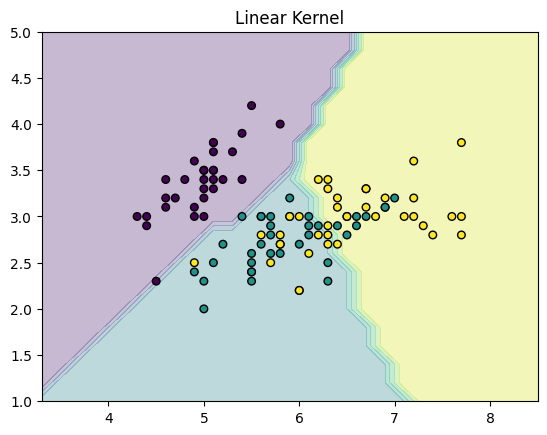

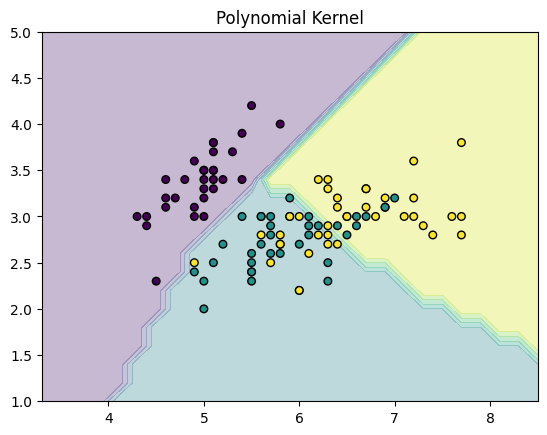

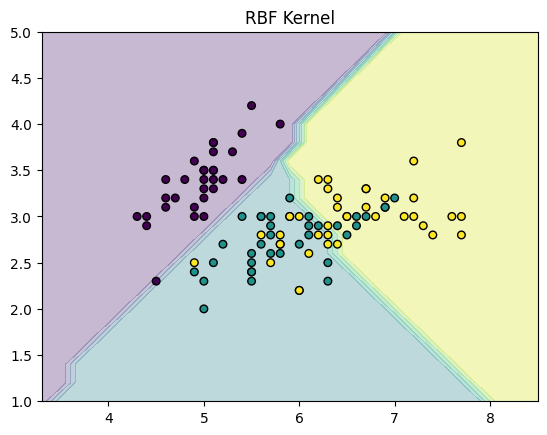

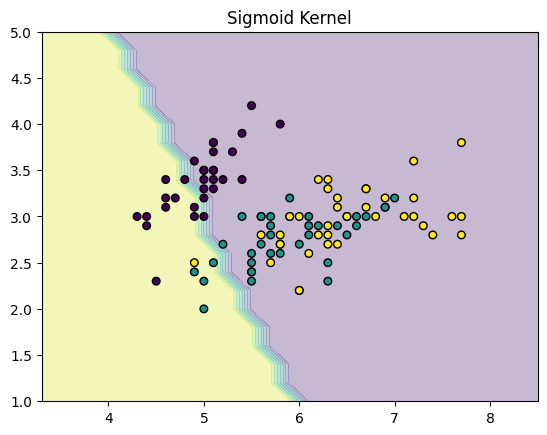

In [17]:
def plot_svm(X, y, model, title):
    h = 0.2
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h))

    Z= model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors='k')
    plt.title(title)
    plt.show()
accuracy_results = {}

for name, model in kernels.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    acc = accuracy_score(y_test, y_pred)
    accuracy_results[name] = acc

    plot_svm(x_train, y_train, model, f"{name} Kernel")